# pandas practice2
온라인 쇼핑몰 주문 데이터를 다루는 실습이다.

범위:
- transformation
- groupby
- visualization_timeseries

규칙:
- 각 문제 아래 코드 셀에서 직접 풀기
- 필요한 경우 셀을 추가해도 된다
- 파일 저장은 현재 작업 폴더 기준으로 진행한다
- 시각화는 기본 형태만 그리면 된다

## 0. 시작 데이터 만들기

실습 안내:
- 이 데이터는 이후 모든 문제에서 공통으로 사용한다.
- 날짜 컬럼은 미리 datetime으로 변환해 둔다.
- 총액은 수량 × 단가로 계산한다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

orders = pd.DataFrame({
    '주문일자': ['2026-01-03', '2026-01-05', '2026-01-05', '2026-01-08', '2026-01-10',
             '2026-02-02', '2026-02-10', '2026-02-18', '2026-03-03', '2026-03-11'],
    '고객명': ['김철수', '이영희', '박민수', '최지영', '정다은', '홍길동', '강민호', '오세훈', '장미라', '서지수'],
    '지역': ['서울', '부산', '서울', '대전', '부산', '서울', '서울', '부산', '대전', '서울'],
    '카테고리': ['전자', '식품', '전자', '패션', '식품', '전자', '패션', '식품', '전자', '패션'],
    '상품명': ['노트북', '사과', '마우스', '자켓', '우유', '키보드', '운동화', '라면', '모니터', '가방'],
    '수량': [1, 10, 2, 1, 3, 1, 2, 5, 1, 1],
    '단가': [1500000, 3000, 25000, 120000, 2500, 50000, 90000, 4000, 350000, 70000]
})

orders['주문일자'] = pd.to_datetime(orders['주문일자'])
orders['총액'] = orders['수량'] * orders['단가']
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000
1,2026-01-05,이영희,부산,식품,사과,10,3000,30000
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000
4,2026-01-10,정다은,부산,식품,우유,3,2500,7500
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000
7,2026-02-18,오세훈,부산,식품,라면,5,4000,20000
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000


## 1. apply / map
1) 총액이 100000 이상이면 '고가', 아니면 '일반'을 반환하는 가격등급 열을 apply로 만드시오.
2) 지역 코드 맵을 사용해 지역코드 열을 map으로 만드시오. (서울:S, 부산:B, 대전:D)

In [2]:
def grade(x):
    if x >= 100000:
        return '고가'
    else:
        return '일반'
orders['등급'] = orders['총액'].apply(grade)
orders

region_map = {'서울':'S', '부산':'B', '대전':'D'}
orders['지역코드'] = orders['지역'].map(region_map)
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,등급,지역코드
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S
1,2026-01-05,이영희,부산,식품,사과,10,3000,30000,일반,B
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D
4,2026-01-10,정다은,부산,식품,우유,3,2500,7500,일반,B
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S
7,2026-02-18,오세훈,부산,식품,라면,5,4000,20000,일반,B
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S


## 2. replace / np.where
1) 카테고리의 '식품'을 '식음료'로 바꾸시오.
2) 총액이 100000 이상이면 VIP, 아니면 NORMAL인 고객등급 열을 np.where로 만드시오.

주의:
- 이후 집계 결과에는 변경된 카테고리명(식음료)이 반영된다.

In [3]:
orders.loc[orders['카테고리'] == '식품', '카테고리'] = '식음료'
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,등급,지역코드
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S
1,2026-01-05,이영희,부산,식음료,사과,10,3000,30000,일반,B
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D
4,2026-01-10,정다은,부산,식음료,우유,3,2500,7500,일반,B
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S
7,2026-02-18,오세훈,부산,식음료,라면,5,4000,20000,일반,B
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S


## 3. np.select
총액 기준으로 주문등급 열을 만드시오.
- 500000 이상: A
- 100000 이상 500000 미만: B
- 그 외: C

In [4]:
cond = [
    orders['총액'] >= 500000,
    orders['총액'] >= 100000,
]
grade = ['A', 'B']
orders['주문등급'] = np.select(cond, grade, default='C')

orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,등급,지역코드,주문등급
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S,A
1,2026-01-05,이영희,부산,식음료,사과,10,3000,30000,일반,B,C
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S,C
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D,B
4,2026-01-10,정다은,부산,식음료,우유,3,2500,7500,일반,B,C
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S,C
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S,B
7,2026-02-18,오세훈,부산,식음료,라면,5,4000,20000,일반,B,C
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D,B
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S,C


## 4. concat
신규 주문 2건이 아래와 같이 들어왔다.
new_orders를 orders와 세로로 연결한 result_concat을 만드시오.

주의:
- 새 주문 데이터에는 아직 일부 파생 컬럼이 없을 수 있다.
- 필요하면 orders의 컬럼 구조에 맞춰 정리한 뒤 연결해도 된다.

In [5]:
new_orders = pd.DataFrame({
    '주문일자': pd.to_datetime(['2026-03-20', '2026-03-25']),
    '고객명': ['한지민', '이도윤'],
    '지역': ['부산', '서울'],
    '카테고리': ['전자', '식음료'],
    '상품명': ['이어폰', '커피'],
    '수량': [2, 4],
    '단가': [80000, 5000],
    '총액': [160000, 20000]
})

result_concat = pd.concat([new_orders, orders])
result_concat

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,등급,지역코드,주문등급
0,2026-03-20,한지민,부산,전자,이어폰,2,80000,160000,NaN,NaN,NaN
1,2026-03-25,이도윤,서울,식음료,커피,4,5000,20000,NaN,NaN,NaN
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S,A
1,2026-01-05,이영희,부산,식음료,사과,10,3000,30000,일반,B,C
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S,C
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D,B
4,2026-01-10,정다은,부산,식음료,우유,3,2500,7500,일반,B,C
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S,C
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S,B
7,2026-02-18,오세훈,부산,식음료,라면,5,4000,20000,일반,B,C


## 5. merge
고객 등급표를 결합하시오.
고객명 기준으로 left join 하여 orders_grade를 만드시오.

확인 포인트:
- 등급표에 없는 고객은 회원등급이 NaN으로 남는다.
- left join이므로 orders의 행 수는 유지된다.

In [6]:
grade_df = pd.DataFrame({
    '고객명': ['김철수', '이영희', '홍길동', '강민호'],
    '회원등급': ['Gold', 'Silver', 'Gold', 'Bronze']
})

orders_grade = pd.merge(orders, grade_df, on = '고객명', how='left')
orders_grade


,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,등급,지역코드,주문등급,회원등급
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S,A,Gold
1,2026-01-05,이영희,부산,식음료,사과,10,3000,30000,일반,B,C,Silver
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S,C,NaN
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D,B,NaN
4,2026-01-10,정다은,부산,식음료,우유,3,2500,7500,일반,B,C,NaN
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S,C,Gold
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S,B,Bronze
7,2026-02-18,오세훈,부산,식음료,라면,5,4000,20000,일반,B,C,NaN
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D,B,NaN
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S,C,NaN


## 6. pivot_table
지역별, 카테고리별 총액 합계를 피벗 테이블로 만드시오.

참고:
- 집계 결과에 따라 값이 없는 조합은 NaN으로 보일 수 있다.

In [7]:
pivot_result = orders.pivot_table(index = '지역', columns = '카테고리', values = '총액', aggfunc = 'sum')
pivot_result

카테고리,식음료,전자,패션
지역,,,
대전,NaN,350000.0,120000.0
부산,57500.0,NaN,NaN
서울,NaN,1600000.0,250000.0


## 7. melt
아래 wide_df를 long 형태로 바꾸시오. 열 이름은 월, 매출을 사용하시오.

In [8]:
wide_df = pd.DataFrame({
    '상품명': ['노트북', '마우스'],
    '1월': [100, 50],
    '2월': [120, 60],
    '3월': [110, 70]
})

pd.melt(
    wide_df,
    id_vars = '상품명',
    value_vars = ['1월', '2월', '3월'],
    var_name = '월',
    value_name = '매출'
)

,상품명,월,매출
0,노트북,1월,100
1,마우스,1월,50
2,노트북,2월,120
3,마우스,2월,60
4,노트북,3월,110
5,마우스,3월,70


## 8. groupby 기본
1) 카테고리별 총액 합계를 구하시오.
2) 지역별 평균 총액을 구하시오.

가능하면 결과를 각각 다른 변수에 저장해보시오.

In [9]:
category_all_sum = orders.groupby('카테고리')['총액'].sum()
print(category_all_sum)
print()
region_all_sum = orders.groupby('지역')['총액'].sum()
print(region_all_sum)

카테고리
식음료      57500
전자     1950000
패션      370000
Name: 총액, dtype: int64

지역
대전     470000
부산      57500
서울    1850000
Name: 총액, dtype: int64


## 9. agg / named aggregation
카테고리별로 아래 값을 한 번에 구하시오.
- 주문수
- 평균총액
- 최고총액

In [10]:
orders.groupby('카테고리').agg(
    주문수 = ('수량', 'count'),
    평균총액 = ('총액', 'mean'),
    최고총액 = ('총액', 'max')
)

,주문수,평균총액,최고총액
카테고리,,,
식음료,3,19166.666667,30000
전자,4,487500.000000,1500000
패션,3,123333.333333,180000


## 10. transform
카테고리 평균 총액을 각 행에 붙이고, 평균대비차이 열을 만드시오.

In [11]:
orders['평균총액'] = orders.groupby('카테고리')['총액'].transform('mean')
orders['평균대비'] = orders['총액'] - orders['평균총액']
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,등급,지역코드,주문등급,평균총액,평균대비
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S,A,487500.000000,1.012500e+06
1,2026-01-05,이영희,부산,식음료,사과,10,3000,30000,일반,B,C,19166.666667,1.083333e+04
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S,C,487500.000000,-4.375000e+05
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D,B,123333.333333,-3.333333e+03
4,2026-01-10,정다은,부산,식음료,우유,3,2500,7500,일반,B,C,19166.666667,-1.166667e+04
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S,C,487500.000000,-4.375000e+05
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S,B,123333.333333,5.666667e+04
7,2026-02-18,오세훈,부산,식음료,라면,5,4000,20000,일반,B,C,19166.666667,8.333333e+02
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D,B,487500.000000,-1.375000e+05
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S,C,123333.333333,-5.333333e+04


## 11. 날짜 처리
1) 주문월 열을 만드시오.
2) 주문요일명 열을 만드시오.

참고:
- `day_name()`은 기본적으로 영어 요일명을 반환한다.

In [12]:
orders['주문월'] = orders['주문일자'].dt.month
orders['주문요일명'] = orders['주문일자'].dt.day_name()
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,등급,지역코드,주문등급,평균총액,평균대비,주문월,주문요일명
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S,A,487500.000000,1.012500e+06,1,Saturday
1,2026-01-05,이영희,부산,식음료,사과,10,3000,30000,일반,B,C,19166.666667,1.083333e+04,1,Monday
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S,C,487500.000000,-4.375000e+05,1,Monday
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D,B,123333.333333,-3.333333e+03,1,Thursday
4,2026-01-10,정다은,부산,식음료,우유,3,2500,7500,일반,B,C,19166.666667,-1.166667e+04,1,Saturday
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S,C,487500.000000,-4.375000e+05,2,Monday
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S,B,123333.333333,5.666667e+04,2,Tuesday
7,2026-02-18,오세훈,부산,식음료,라면,5,4000,20000,일반,B,C,19166.666667,8.333333e+02,2,Wednesday
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D,B,487500.000000,-1.375000e+05,3,Tuesday
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S,C,123333.333333,-5.333333e+04,3,Wednesday


## 12. 시계열 인덱스와 리샘플링
1) 주문일자를 인덱스로 설정한 ts_orders를 만드시오.
2) 월말 기준 월별 총액 합계를 구하시오.

In [ ]:
ts_orders = pd.DataFrame({
    '날짜': orders['주문일자'],
    '매출': orders['총액']
}).set_index('날짜')
display(ts_orders)

ts_orders['월별_총액_합계'] = ts_orders.sum()
# ts_orders.resample('ME').sum()
ts_orders


,매출
날짜,
2026-01-03,1500000
2026-01-05,30000
2026-01-05,50000
2026-01-08,120000
2026-01-10,7500
2026-02-02,50000
2026-02-10,180000
2026-02-18,20000
2026-03-03,350000


,매출,월별_총액_합계
날짜,,
2026-01-03,1500000,NaN
2026-01-05,30000,NaN
2026-01-05,50000,NaN
2026-01-08,120000,NaN
2026-01-10,7500,NaN
2026-02-02,50000,NaN
2026-02-10,180000,NaN
2026-02-18,20000,NaN
2026-03-03,350000,NaN


## 13. rolling
일자별 총액 합계를 구한 뒤 3일 이동평균을 계산하시오.

참고:
- 일 단위로 리샘플링하면 주문이 없는 날짜도 포함될 수 있다.

In [27]:
ts_orders['이동평균_3일'] = ts_orders['매출'].rolling(3).mean()
ts_orders

,매출,월별_총액_합계,이동평균_3일
날짜,,,
2026-01-03,1500000,NaN,NaN
2026-01-05,30000,NaN,NaN
2026-01-05,50000,NaN,526666.666667
2026-01-08,120000,NaN,66666.666667
2026-01-10,7500,NaN,59166.666667
2026-02-02,50000,NaN,59166.666667
2026-02-10,180000,NaN,79166.666667
2026-02-18,20000,NaN,83333.333333
2026-03-03,350000,NaN,183333.333333


## 14. shift / diff / pct_change
일자별 총액 합계를 기준으로
- 전일총액
- 전일대비
- 변화율
열을 만드시오.

참고:
- 전일 값이 0인 경우 변화율 해석에 주의한다.

In [28]:
ts_orders['전일총액'] = ts_orders['매출'].shift(1)
ts_orders['전일대비'] = ts_orders['매출'].diff()
ts_orders['변화율'] = ts_orders['매출'].pct_change()

ts_orders

,매출,월별_총액_합계,이동평균_3일,전일총액,전일대비,변화율
날짜,,,,,,
2026-01-03,1500000,NaN,NaN,NaN,NaN,NaN
2026-01-05,30000,NaN,NaN,1500000.0,-1470000.0,-0.980000
2026-01-05,50000,NaN,526666.666667,30000.0,20000.0,0.666667
2026-01-08,120000,NaN,66666.666667,50000.0,70000.0,1.400000
2026-01-10,7500,NaN,59166.666667,120000.0,-112500.0,-0.937500
2026-02-02,50000,NaN,59166.666667,7500.0,42500.0,5.666667
2026-02-10,180000,NaN,79166.666667,50000.0,130000.0,2.600000
2026-02-18,20000,NaN,83333.333333,180000.0,-160000.0,-0.888889
2026-03-03,350000,NaN,183333.333333,20000.0,330000.0,16.500000


## 15. 시각화
1) 월별 총액 합계를 막대 그래프로 그리시오.
2) 일자별 총액과 3일 이동평균을 선 그래프로 그리시오.

<Axes: xlabel='날짜'>

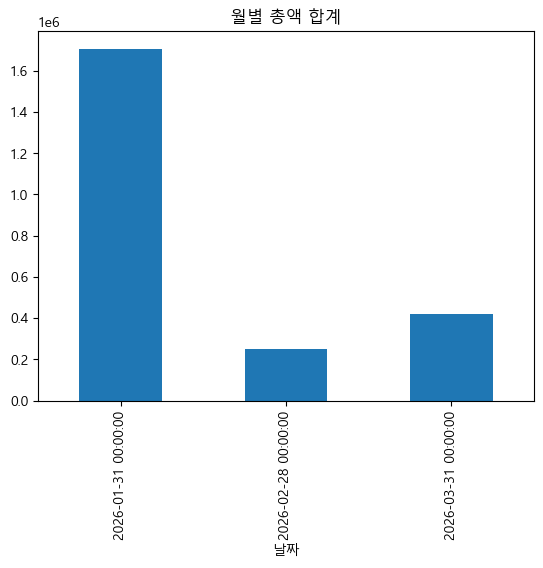

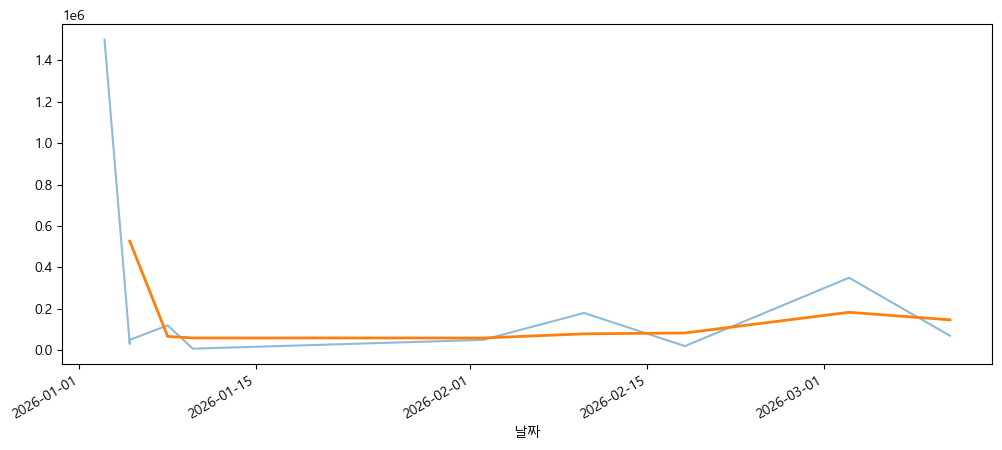

In [30]:
monthly = ts_orders.resample('ME')['매출'].sum()
monthly.plot(kind='bar', title='월별 총액 합계')

fig, ax = plt.subplots(figsize=(12, 5))

ts_orders['매출'].plot(ax=ax, alpha=0.5, label = '일자별 총액')
ts_orders['이동평균_3일'].plot(ax=ax, linewidth=2, label='3일 이동평균')